In [130]:
import numpy as np
import matplotlib.pyplot as plt
from visualization import draw_field_with_robot
from particle_filter import *
from Localization_metrics import *

## Настройка параметров модели фильтра частиц

In [131]:
particles_count = 3000  # hyperparam: particles count 

# landmark coords
left_coord = Coord(-1, 5)
right_coord = Coord(1, 5)
lm = LandMark(left_coord, right_coord)

# standard deviation of noise for each dimension (x, y, theta)
system_noise = State(0.2, 0.2, 0.2)
sens_noise = np.array([0.05, 0.05, 0.05])

# initial state
state0 = State(0, 0, np.pi/2)

pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)
local_metrics = LocalizationMetrics()

## Хождение робота на поле

In [132]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

# steps_cnt = int(input())
# trajectory = [(pf.state.x, pf.state.y)]

# fig, ax = plt.subplots(figsize=(8, 10))
# draw_field_with_robot(pf.state, pf.particles, ax=ax)
# display(fig)

# for i in range(steps_cnt):
#     step = State(*map(float, input().split()))
#     est_state = pf.simulate(step)
    
#     local_metrics.update(pf.ideal_state, est_state)
#     trajectory.append((est_state.x, est_state.y))

#     draw_field_with_robot(est_state, pf.particles, ax=ax)

#     traj = np.array(trajectory)
#     ax.plot(traj[:, 0], traj[:, 1], color='red', linewidth=2)   # от стартовой точки
#     ax.plot(traj[:, 0], traj[:, 1], 'ko', markersize=3)          # узловые точки пути

#     clear_output(wait=True)
#     display(fig)

#     # print("estimated state: ", est_state)
#     # print("true state: ", pf.state)

# plt.close(fig)

# res = local_metrics.summary()

In [133]:
# # метрики оценки качества локализации
# res

## Эксперменты

#### Насколько сильно шум движения ухудшает локализацию без PF?
#### Насколько PF компенсирует эту ошибку?
#### Как качество PF зависит от шума сенсора и количества частиц?

In [134]:
# заданный маршрут робота
steps = [
    # ↑ к воротам
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # → вправо
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ←
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑ к воротам
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
]

# начальное положение робота
state0 = State(0, -4, np.pi / 2)

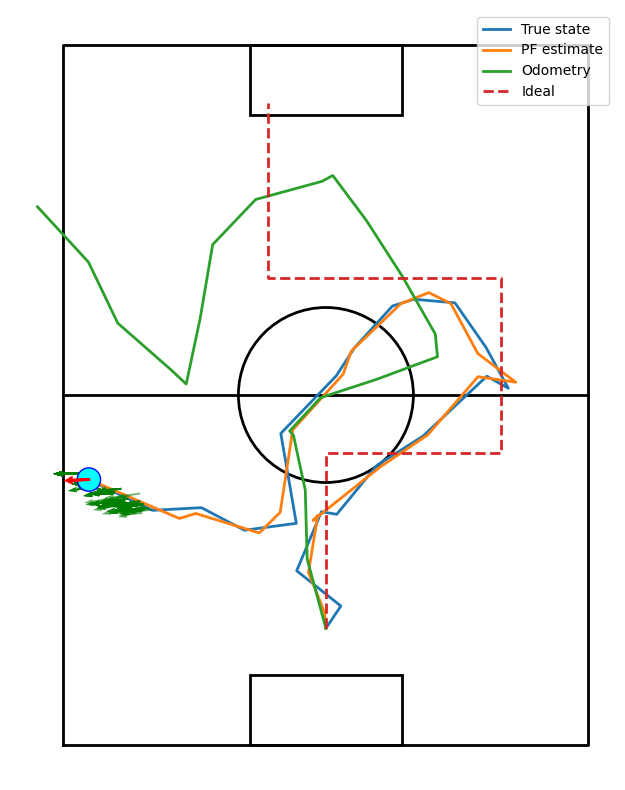

In [135]:
# насколько PF определяет фактическое положение робота
pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)

pf_metrics_state = LocalizationMetrics()
no_pf_metrics_state = LocalizationMetrics()
pf_metrics_ideal_state = LocalizationMetrics()
no_pf_metrics_ideal_state = LocalizationMetrics()

fig, ax = plt.subplots(figsize=(8, 10))
draw_field_with_robot(pf.state, pf.particles, ax=ax)
display(fig)

true_trajectory = [(pf.state.x, pf.state.y)]
pf_trajectory = [(pf.state.x, pf.state.y)]
no_pf_trajectory = [(pf.no_pf_state.x, pf.no_pf_state.y)]
ideal_trajectory = [(pf.ideal_state.x, pf.ideal_state.y)]

for step_i in steps:

    est_state = pf.simulate(step_i)

    pf_metrics_state.update(pf.state, est_state)
    no_pf_metrics_state.update(pf.state, pf.no_pf_state)

    pf_metrics_ideal_state.update(pf.ideal_state, est_state)
    no_pf_metrics_ideal_state.update(pf.ideal_state, pf.no_pf_state)

    true_trajectory.append((pf.state.x, pf.state.y))
    pf_trajectory.append((est_state.x, est_state.y))
    no_pf_trajectory.append((pf.no_pf_state.x, pf.no_pf_state.y))
    ideal_trajectory.append((pf.ideal_state.x, pf.ideal_state.y))

    draw_field_with_robot(est_state, pf.particles, ax=ax)

    true_traj = np.array(true_trajectory)
    pf_traj = np.array(pf_trajectory)
    no_pf_traj = np.array(no_pf_trajectory)
    id_traj = np.array(ideal_trajectory)

    ax.plot(true_traj[:, 0], true_traj[:, 1],
            linewidth=2, label='True state')

    ax.plot(pf_traj[:, 0], pf_traj[:, 1],
            linewidth=2, label='PF estimate')

    ax.plot(no_pf_traj[:, 0], no_pf_traj[:, 1],
            linewidth=2, label='Odometry')
    
    ax.plot(id_traj[:, 0], id_traj[:, 1],
            linewidth=2, linestyle='--', label='Ideal')

    ax.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

res_pf_state = pf_metrics_state.summary()
res_no_pf_state = no_pf_metrics_state.summary()
res_pf_ideal_state = pf_metrics_ideal_state.summary()
res_no_pf_ideal_state = no_pf_metrics_ideal_state.summary()

Качество локализации

In [136]:
res_pf_state

{'position_rmse': np.float64(0.2260802255976375),
 'position_mae': np.float64(0.1943701007014782),
 'position_max': np.float64(0.48157596582465956),
 'position_final': np.float64(0.1102745089129562),
 'angle_rmse': np.float64(0.05362561755986396)}

In [137]:
res_no_pf_state

{'position_rmse': np.float64(2.5644359092385227),
 'position_mae': np.float64(2.3396511980183035),
 'position_max': np.float64(4.697031761903431),
 'position_final': np.float64(4.697031761903431),
 'angle_rmse': np.float64(0.6097761053602083)}

res_pf_state всегда лучше res_no_pf_state

Отклонение от заданного маршрута

In [138]:
res_pf_ideal_state

{'position_rmse': np.float64(3.010908692714481),
 'position_mae': np.float64(2.282567905442618),
 'position_max': np.float64(7.139779836468183),
 'position_final': np.float64(7.139779836468183),
 'angle_rmse': np.float64(1.1259430410009885)}

In [139]:
res_no_pf_ideal_state

{'position_rmse': np.float64(2.5792210491998286),
 'position_mae': np.float64(2.3274394926156607),
 'position_max': np.float64(4.324063237436769),
 'position_final': np.float64(4.324063237436769),
 'angle_rmse': np.float64(0.6137099298513029)}

### Усредняем по n seedам

In [ ]:
pf_ideal_rmses = []
no_pf_ideal_rmses = []
particles_count = 2000

n = 50
for seed_i in range(n):
    np.random.seed(seed_i)
    random.seed(seed_i)
    pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)

    pf_metrics_ideal_state = LocalizationMetrics()
    no_pf_metrics_ideal_state = LocalizationMetrics()
    
    for step_i in steps:
        est_state = pf.simulate(step_i)

        # Близость к идеальной траектории

        # ideal и оценка PF
        pf_metrics_ideal_state.update(
            pf.ideal_state,
            est_state
        )

        # ideal и оценка одометрии
        no_pf_metrics_ideal_state.update(
            pf.ideal_state,
            pf.no_pf_state
        )

    pf_result = pf_metrics_ideal_state.summary()
    no_pf_result = no_pf_metrics_ideal_state.summary()

    pf_pos_rmse = pf_result["position_rmse"]
    odom_pos_rmse = no_pf_result["position_rmse"]

    pf_ideal_rmses.append(pf_pos_rmse)
    no_pf_ideal_rmses.append(odom_pos_rmse)

    print(f"Iter num:{seed_i}: pf_pos_rmse: {pf_pos_rmse}, odom_pos_rmse: {odom_pos_rmse}")
    

Iter num:0: pf_pos_rmse: 3.832024184133781, odom_pos_rmse: 2.6032779095159553
Iter num:1: pf_pos_rmse: 2.283977499975236, odom_pos_rmse: 2.7249308451278074
Iter num:2: pf_pos_rmse: 3.284484016796814, odom_pos_rmse: 2.8934216557466628
Iter num:3: pf_pos_rmse: 5.123024092900963, odom_pos_rmse: 2.911736485309054
Iter num:4: pf_pos_rmse: 4.625707057230904, odom_pos_rmse: 5.3010322740100255
Iter num:5: pf_pos_rmse: 1.5929118622372658, odom_pos_rmse: 1.583792137686005
Iter num:6: pf_pos_rmse: 1.176845607168002, odom_pos_rmse: 2.480099090501802
Iter num:7: pf_pos_rmse: 1.7277391660398946, odom_pos_rmse: 2.091553992018773
Iter num:8: pf_pos_rmse: 3.7279661559420503, odom_pos_rmse: 1.4648829508807626
Iter num:9: pf_pos_rmse: 1.9242093442234236, odom_pos_rmse: 2.9544150410929415
Iter num:10: pf_pos_rmse: 2.924780884273648, odom_pos_rmse: 2.9412791819113235
Iter num:11: pf_pos_rmse: 2.3812874838174913, odom_pos_rmse: 1.4112629110465005
Iter num:12: pf_pos_rmse: 1.7188609940958648, odom_pos_rmse: 

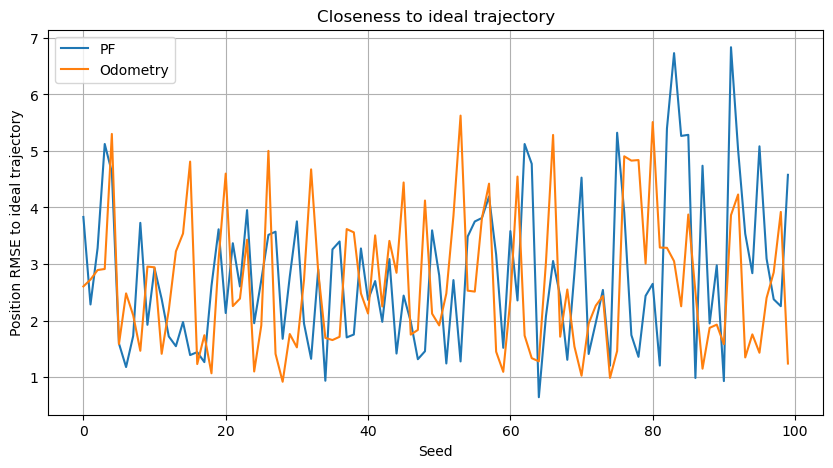

In [141]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(n),
    pf_ideal_rmses,
    label="PF"
)

ax.plot(
    range(n),
    no_pf_ideal_rmses,
    label="Odometry"
)

ax.set_xlabel("Seed")
ax.set_ylabel("Position RMSE to ideal trajectory")
ax.set_title("Closeness to ideal trajectory")
ax.legend()
ax.grid()

plt.show()

In [142]:
print(np.mean(pf_ideal_rmses))
print(np.mean(no_pf_ideal_rmses))

2.8128592420324026
2.6800720659348


### PF в среднем несколько ближе к заданной идеальной траектории, чем одометрия.